In [98]:
from mplsoccer import Sbopen
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

import torch
from torch import nn

#warnings not visible on the course webpage
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [3]:
parser = Sbopen()
#get list of games during Indian Super League season
df_match = parser.match(competition_id=1238, season_id=108)

matches = df_match.match_id.unique()

shot_df = pd.DataFrame()
track_df = pd.DataFrame()
#store data in one dataframe
for match in matches:
    #open events
    df_event = parser.event(match)[0]
    #open 360 data
    df_track = parser.event(match)[2]
    #get shots
    shots = df_event.loc[df_event["type_name"] == "Shot"]
    shots.x = shots.x.apply(lambda cell: cell*105/120)
    shots.y = shots.y.apply(lambda cell: cell*68/80)
    df_track.x = df_track.x.apply(lambda cell: cell*105/120)
    df_track.y = df_track.y.apply(lambda cell: cell*68/80)
    #append event and trackings to a dataframe
    shot_df = pd.concat([shot_df, shots], ignore_index = True)
    track_df = pd.concat([track_df, df_track], ignore_index = True)

#reset indicies
shot_df.reset_index(drop=True, inplace=True)
track_df.reset_index(drop=True, inplace=True)
#filter out non open-play shots
shot_df = shot_df.loc[shot_df["sub_type_name"] == "Open Play"]
#filter out shots where goalkeeper was not tracked
gks_tracked = track_df.loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"]['id'].unique()
shot_df = shot_df.loc[shot_df["id"].isin(gks_tracked)]
shot_df

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,shot_deflected,shot_open_goal,ball_recovery_offensive,pass_miscommunication,player_off_permanent,dribble_no_touch,foul_committed_penalty,foul_won_penalty,shot_follows_dribble,shot_redirect
0,f4889f42-cf51-4c27-8c8d-d57040b17ce1,368,1,00:10:08.014000,10,8,26,1.123674,3827767,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3e3c20ab-5233-479f-877e-73b94d01a963,495,1,00:13:50.965000,13,50,31,0.967366,3827767,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,f6fa4021-385f-4353-9e41-81a9ade1d2ac,731,1,00:20:16.861000,20,16,44,1.271256,3827767,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3c75ac72-8c43-4ca4-b6f4-2d38dc58c8c7,1069,1,00:29:18.678000,29,18,68,0.216327,3827767,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,49c30b55-a2df-4b6e-84fa-101457ed2d08,1356,1,00:38:25.380000,38,25,82,0.962666,3827767,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,afcb0f9b-b091-45d1-8908-c315ef442c2c,2643,2,00:34:27.087000,79,27,149,0.538824,3813264,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3091,5b1584ca-2c81-48b5-9958-1a63305e9e4d,2648,2,00:35:02.379000,80,2,150,0.724816,3813264,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3092,505c3c52-3618-474f-81bb-b6f5b66cce9a,2698,2,00:38:33.655000,83,33,160,0.216856,3813264,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3093,1732c372-68e7-49d5-bd45-0acba3bf34bf,2703,2,00:38:34.834000,83,34,160,0.392550,3813264,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#take important variables from shot dataframe
model_vars = shot_df[["id", "index", "x", "y"]]
#get the dependent variable
model_vars["goal"] = shot_df.outcome_name.apply(lambda cell: 1 if cell == "Goal" else 0)
#change the dependent variable to object for basic xG modelling
model_vars["goal_smf"] = model_vars["goal"].astype(object)
# ball location (x)
model_vars['x0'] = model_vars.x
# x to calculate angle and distance
model_vars["x"] = model_vars.x.apply(lambda cell: 105-cell)
# c to calculate angle and distance between ball and the goal as in Lesson 2
model_vars["c"] = model_vars.y.apply(lambda cell: abs(34-cell))
#calculating angle and distance as in Lesson 2
model_vars["angle"] = np.where(np.arctan(7.32 * model_vars["x"] / (model_vars["x"]**2 + model_vars["c"]**2 - (7.32/2)**2)) >= 0, np.arctan(7.32 * model_vars["x"] /(model_vars["x"]**2 + model_vars["c"]**2 - (7.32/2)**2)), np.arctan(7.32 * model_vars["x"] /(model_vars["x"]**2 + model_vars["c"]**2 - (7.32/2)**2)) + np.pi)*180/np.pi
model_vars["distance"] = np.sqrt(model_vars["x"]**2 + model_vars["c"]**2)
model_vars

,id,index,x,y,goal,goal_smf,x0,c,angle,distance
0,f4889f42-cf51-4c27-8c8d-d57040b17ce1,368,25.5500,16.150,0,0,79.4500,17.850,11.046323,31.167692
1,3e3c20ab-5233-479f-877e-73b94d01a963,495,7.1750,33.405,0,0,97.8250,0.595,53.800363,7.199628
2,f6fa4021-385f-4353-9e41-81a9ade1d2ac,731,22.8375,41.735,0,0,82.1625,7.735,16.400290,24.111857
3,3c75ac72-8c43-4ca4-b6f4-2d38dc58c8c7,1069,26.0750,15.980,0,0,78.9250,18.020,10.899337,31.695836
4,49c30b55-a2df-4b6e-84fa-101457ed2d08,1356,13.5625,47.515,0,0,91.4375,13.515,15.699574,19.146713
...,...,...,...,...,...,...,...,...,...,...
3090,afcb0f9b-b091-45d1-8908-c315ef442c2c,2643,9.9750,28.390,0,0,95.0250,5.610,31.840846,11.444332
3091,5b1584ca-2c81-48b5-9958-1a63305e9e4d,2648,4.8125,37.995,0,0,100.1875,3.995,53.861532,6.254613
3092,505c3c52-3618-474f-81bb-b6f5b66cce9a,2698,15.5750,41.310,0,0,89.4250,7.310,21.969085,17.205137
3093,1732c372-68e7-49d5-bd45-0acba3bf34bf,2703,15.6625,41.735,0,0,89.3375,7.735,21.453521,17.468375


In [5]:
#calculating basic xG using logistic regression
def params(df):
    test_model = smf.glm(formula="goal_smf ~ angle + distance", data=df,
                               family=sm.families.Binomial()).fit()
    #print summary
    return test_model.params

def calculate_xG(sh, b):
   bsum=b[0]
   for i,v in enumerate(["angle", "distance"]):
       bsum=bsum+b[i+1]*sh[v]
   xG = 1/(1+np.exp(bsum))
   return xG

#ball_goalkeeper distance
def dist_to_gk(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #check goalkeeper position
    gk_pos = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"][["x", "y"]]
    #calculate distance from event to goalkeeper position
    dist = np.sqrt((test_shot["x"] - gk_pos["x"])**2 + (test_shot["y"] - gk_pos["y"])**2)
    return dist.iloc[0]

#ball goalkeeper y axis
def y_to_gk(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #calculate distance from event to goalkeeper position
    gk_pos = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"][["y"]]
    #calculate distance from event to goalkeeper position in y axis
    dist = abs(test_shot["y"] - gk_pos["y"])
    return dist.iloc[0]

#number of players less than 3 meters away from the ball
def three_meters_away(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #get all opposition's player location
    player_position = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False][["x", "y"]]
    #calculate their distance to the ball
    dist = np.sqrt((test_shot["x"] - player_position["x"])**2 + (test_shot["y"] - player_position["y"])**2)
    #return how many are closer to the ball than 3 meters
    return len(dist[dist<3])

#number of players inside a triangle
def players_in_triangle(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #get all opposition's player location
    player_position = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False][["x", "y"]]
    #checking if point inside a triangle
    x1 = 105
    y1 = 34 - 7.32/2
    x2 = 105
    y2 = 34 + 7.32/2
    x3 = test_shot["x"]
    y3 = test_shot["y"]
    xp = player_position["x"]
    yp = player_position["y"]
    c1 = (x2-x1)*(yp-y1)-(y2-y1)*(xp-x1)
    c2 = (x3-x2)*(yp-y2)-(y3-y2)*(xp-x2)
    c3 = (x1-x3)*(yp-y3)-(y1-y3)*(xp-x3)
    #get number of players inside a triangle
    return len(player_position.loc[((c1<0) & (c2<0) & (c3<0)) | ((c1>0) & (c2>0) & (c3>0))])

#goalkeeper distance to goal
def gk_dist_to_goal(test_shot, track_df):
    #get id of the shot to search for tracking data using this index
    test_shot_id = test_shot["id"]
    #get goalkeeper position
    gk_pos = track_df.loc[track_df["id"] == test_shot_id].loc[track_df["teammate"] == False].loc[track_df["position_name"] == "Goalkeeper"][["x", "y"]]
    #calculate their distance to goal
    dist = np.sqrt((105 -gk_pos["x"])**2 + (34 - gk_pos["y"])**2)
    return dist.iloc[0]

In [6]:
#expected goals based on distance to goal and angle between the ball and the goal
b = params(model_vars)
model_vars["xg_basic"]= model_vars.apply(calculate_xG, b = b, axis=1)
#store distance from event to goalkeeper position in a dataframe
model_vars["gk_distance"] = shot_df.apply(dist_to_gk, track_df = track_df, axis = 1)
#store distance in y axis from event to goalkeeper position in a dataframe
model_vars["gk_distance_y"] = shot_df.apply(y_to_gk, track_df = track_df, axis = 1)
#store number of opposition's players closer than 3 meters in a dataframe
model_vars["close_players"] = shot_df.apply(three_meters_away, track_df = track_df, axis = 1)
#store number of opposition's players inside a triangle in a dataframe
model_vars["triangle"] = shot_df.apply(players_in_triangle, track_df = track_df, axis = 1)
#store opposition's goalkeeper distance to goal in a dataframe
model_vars["gk_dist_to_goal"] = shot_df.apply(gk_dist_to_goal, track_df = track_df, axis = 1)
#create binary varibale 1 if ball is closer to the goal than goalkeeper
model_vars["is_closer"] = np.where(model_vars["gk_dist_to_goal"] > model_vars["distance"], 1, 0)
#create binary variable 1 if header
model_vars["header"] = shot_df.body_part_name.apply(lambda cell: 1 if cell == "Head" else 0)
model_vars

,id,index,x,y,goal,goal_smf,x0,c,angle,distance,xg_basic,gk_distance,gk_distance_y,close_players,triangle,gk_dist_to_goal,is_closer,header
0,f4889f42-cf51-4c27-8c8d-d57040b17ce1,368,25.5500,16.150,0,0,79.4500,17.850,11.046323,31.167692,0.026873,29.555469,16.660,0,2,1.646210,0,0
1,3e3c20ab-5233-479f-877e-73b94d01a963,495,7.1750,33.405,0,0,97.8250,0.595,53.800363,7.199628,0.230643,6.328035,0.595,2,1,0.875000,0,1
2,f6fa4021-385f-4353-9e41-81a9ade1d2ac,731,22.8375,41.735,0,0,82.1625,7.735,16.400290,24.111857,0.044003,22.043447,6.970,1,1,2.071437,0,0
3,3c75ac72-8c43-4ca4-b6f4-2d38dc58c8c7,1069,26.0750,15.980,0,0,78.9250,18.020,10.899337,31.695836,0.026060,30.327900,17.510,0,2,1.408104,0,0
4,49c30b55-a2df-4b6e-84fa-101457ed2d08,1356,13.5625,47.515,0,0,91.4375,13.515,15.699574,19.146713,0.055353,16.224501,11.305,1,1,2.930823,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,afcb0f9b-b091-45d1-8908-c315ef442c2c,2643,9.9750,28.390,0,0,95.0250,5.610,31.840846,11.444332,0.118444,9.686647,4.335,0,1,1.829831,0,1
3091,5b1584ca-2c81-48b5-9958-1a63305e9e4d,2648,4.8125,37.995,0,0,100.1875,3.995,53.861532,6.254613,0.239834,3.857156,1.955,2,3,2.524729,0,1
3092,505c3c52-3618-474f-81bb-b6f5b66cce9a,2698,15.5750,41.310,0,0,89.4250,7.310,21.969085,17.205137,0.071111,15.874502,6.970,0,3,1.355823,0,0
3093,1732c372-68e7-49d5-bd45-0acba3bf34bf,2703,15.6625,41.735,0,0,89.3375,7.735,21.453521,17.468375,0.069322,16.065644,7.395,1,2,1.440694,0,0


In [ ]:
#store dependent variable in a numpy array
y = model_vars["goal"].values
#store independent variables in a numpy array
X = model_vars[["x0", "is_closer", "angle", "distance", "gk_distance", "gk_distance_y", "triangle", "close_players", "header", "xg_basic"]].values
print(X.shape, y.shape)

(2875, 10) (2875,)


In [104]:
#split the data to train, validation and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.6, random_state = 123, stratify = y)
X_cal, X_val, y_cal, y_val  = train_test_split(X_test, y_test, train_size = 0.5, random_state = 123, stratify = y_test)
#scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_cal = scaler.transform(X_cal)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_cal = torch.tensor(X_cal, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_cal = torch.tensor(y_cal, dtype=torch.float32).unsqueeze(1)

In [105]:
model = nn.Sequential(
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
            nn.Sigmoid(),
        )

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [106]:
# Training loop
history = []
for epoch in range(1000):
    model.train()

    # Forward pass
    y_pred = model(X_train)

    # Compute loss
    loss = loss_fn(y_pred, y_train)
    history.append(loss.item())

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

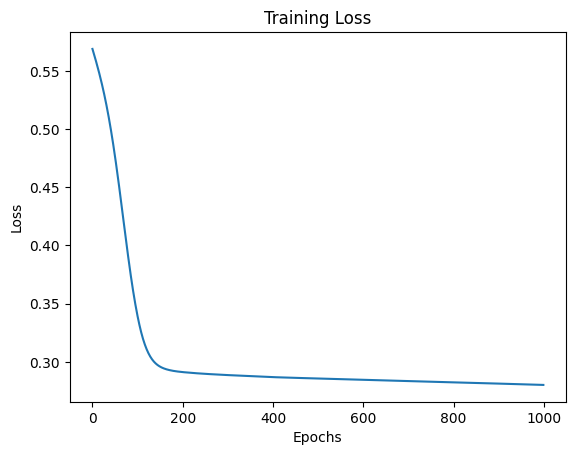

In [107]:
fig = plt.figure()
axs = fig.add_subplot(1, 1, 1)
#plot training history - loss function
axs.plot(history, label='train')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.set_title('Training Loss')
plt.show()

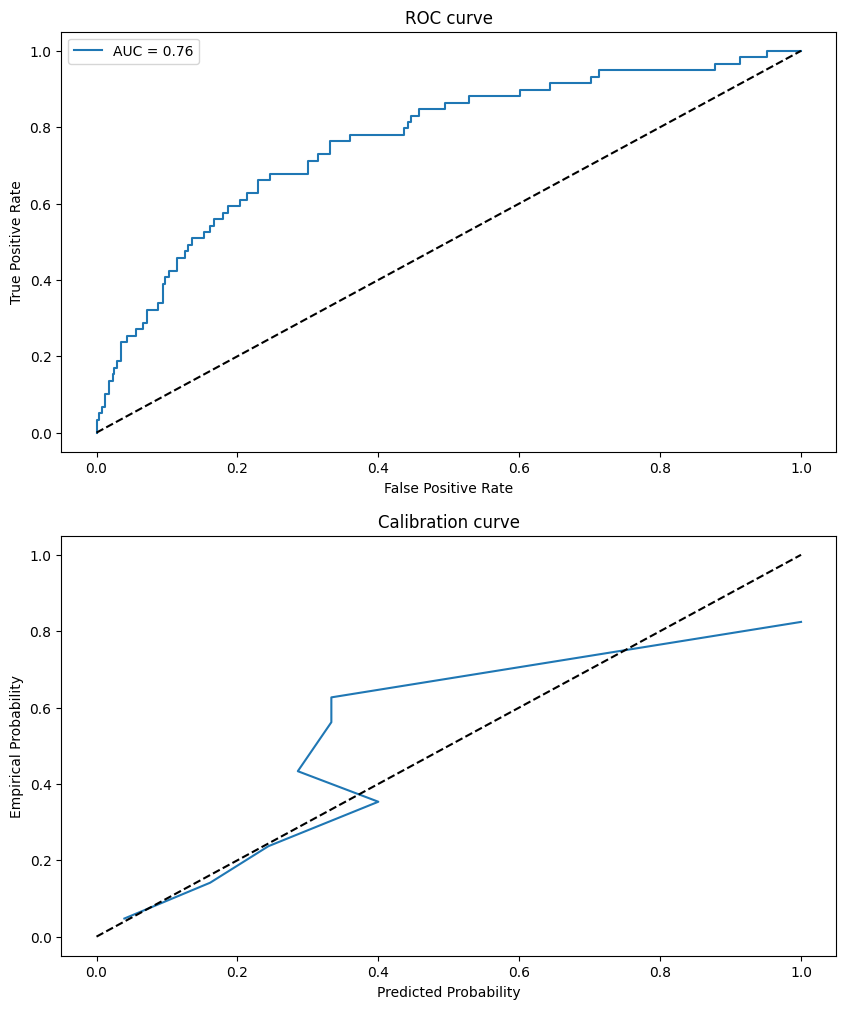

Brier score 0.0823468919436693


In [110]:
#ROC CURVE
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss
fig, axs = plt.subplots(2, figsize=(10,12))
y_pred = model(X_cal).detach().numpy()
fpr, tpr, _ = roc_curve(y_cal,  y_pred)
auc = roc_auc_score(y_cal, y_pred)
axs[0].plot(fpr,tpr,label= "AUC = " + str(auc)[:4])
axs[0].plot([0, 1], [0, 1], color='black', ls = '--')
axs[0].legend()
axs[0].set_ylabel('True Positive Rate')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_title('ROC curve')

#CALIBRATION CURVE
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_cal, y_pred, n_bins=10)
axs[1].plot(prob_true, prob_pred)
axs[1].plot([0, 1], [0, 1], color='black', ls = '--')
axs[1].set_ylabel('Empirical Probability')
axs[1].set_xlabel('Predicted Probability')
axs[1].set_title("Calibration curve")
plt.show()
#Brier score
print("Brier score", brier_score_loss(y_cal, y_pred))

In [112]:
#getting trackings and events for UEFA Euro the same way as we did for Indian Super League
df_match2 = parser.match(competition_id=55, season_id=43)
#get array of match ids
matches2 = df_match2.match_id.unique()
shot_df2 = pd.DataFrame()
track_df2 = pd.DataFrame()
#for each match store shots and trackings in dataframes for the entire season
for match in matches2:
    df_event = parser.event(match)[0]
    df_track = parser.event(match)[2]
    shots = df_event.loc[df_event["type_name"] == "Shot"]
    shots.x = shots.x.apply(lambda cell: cell*105/120)
    shots.y = shots.y.apply(lambda cell: cell*68/80)
    df_track.x = df_track.x.apply(lambda cell: cell*105/120)
    df_track.y = df_track.y.apply(lambda cell: cell*68/80)

    shot_df2 = pd.concat([shot_df2, shots], ignore_index = True)
    track_df2 = pd.concat([track_df2, df_track], ignore_index = True)

#reset indicies and remove shots that were not open play or when the goalkeeper was not tracked
shot_df2 = shot_df2.loc[shot_df2["sub_type_name"] == "Open Play"]
shot_df2.reset_index(drop=True, inplace=True)
track_df2.reset_index(drop=True, inplace=True)
gks_tracked2 = track_df2.loc[track_df2["teammate"] == False].loc[track_df2["position_name"] == "Goalkeeper"]['id'].unique()
shot_df2 = shot_df2.loc[shot_df2["id"].isin(gks_tracked2)]

#DATA WRANGLING. DESCRIPTION OF THESE STEPS CAN BE FOUND IN FEATURE ENGINEERING PART
model_vars2 = shot_df2[["id", "index", "x", "y"]]
model_vars2["goal"] = shot_df2.outcome_name.apply(lambda cell: 1 if cell == "Goal" else 0)
model_vars2["goal_smf"] = model_vars2["goal"].astype(object)
model_vars2['x0'] = model_vars2.x
model_vars2["x"] = model_vars2.x.apply(lambda cell: 105-cell)
model_vars2["c"] = model_vars2.y.apply(lambda cell: abs(34-cell))
model_vars2["angle"] = np.where(np.arctan(7.32 * model_vars2["x"] / (model_vars2["x"]**2 + model_vars2["c"]**2 - (7.32/2)**2)) >= 0, np.arctan(7.32 * model_vars2["x"] /(model_vars2["x"]**2 + model_vars2["c"]**2 - (7.32/2)**2)), np.arctan(7.32 * model_vars2["x"] /(model_vars2["x"]**2 + model_vars2["c"]**2 - (7.32/2)**2)) + np.pi)*180/np.pi
model_vars2["distance"] = np.sqrt(model_vars2["x"]**2 + model_vars2["c"]**2)
model_vars2["xg_basic"]= model_vars2.apply(calculate_xG, b = b, axis=1)
model_vars2["gk_distance"] = shot_df2.apply(dist_to_gk, track_df = track_df2, axis = 1)
model_vars2["gk_distance_y"] = shot_df2.apply(y_to_gk, track_df = track_df2, axis = 1)
model_vars2["triangle"] = shot_df2.apply(players_in_triangle, track_df = track_df2, axis = 1)
model_vars2["close_players"] = shot_df2.apply(three_meters_away, track_df = track_df2, axis = 1)
model_vars2["gk_dist_to_goal"] = shot_df2.apply(gk_dist_to_goal, track_df = track_df2, axis = 1)
model_vars2["is_closer"] = np.where(model_vars2["gk_dist_to_goal"] > model_vars2["distance"], 1, 0)
model_vars2["header"] = shot_df2.body_part_name.apply(lambda cell: 1 if cell == "Head" else 0)
model_vars2

,id,index,x,y,goal,goal_smf,x0,c,angle,distance,xg_basic,gk_distance,gk_distance_y,triangle,close_players,gk_dist_to_goal,is_closer,header
0,71b729f2-d1a8-4a33-8c1d-95855f06f068,73,24.5875,33.150,0,0,80.4125,0.850,16.913826,24.602188,0.043497,20.580061,0.850,2,0,4.025000,0,0
1,61e0923b-902b-4138-bf1e-0f190ab10a39,401,20.5625,25.245,0,0,84.4375,8.755,17.205749,22.348746,0.049036,20.040090,7.140,3,0,2.446351,0,0
2,7a5dbc86-0794-48c8-a3e7-cba9566fd353,1017,7.0000,34.595,0,0,98.0000,0.595,54.940176,7.025242,0.237682,6.195954,0.935,2,1,0.938736,0,1
3,3b4a26fc-1849-430d-83b7-5e83b81b0cc5,1450,17.7625,49.810,0,0,87.2375,15.810,13.252655,23.779456,0.041317,20.585472,13.855,1,2,3.203269,0,0
4,b9069cb8-da1f-4529-9ba9-b4366d36777d,1458,5.9500,33.915,0,0,99.0500,0.085,63.185940,5.950607,0.290852,5.354394,0.425,2,2,0.797030,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,fc1870b7-9e79-435f-bdd0-985ec3c7c0cf,2612,21.4375,26.860,0,0,83.5625,7.140,17.517984,22.595265,0.048820,20.391975,6.205,2,0,2.219095,0,0
1189,1f9e4fd6-bf9b-413a-84da-65c617d3f6e9,2658,18.0250,41.480,0,0,86.9750,7.480,19.751799,19.515405,0.060127,16.491844,6.545,3,1,3.035108,0,0
1190,bb834fde-109d-41d7-8ae6-abb4ed446841,2692,21.9625,34.680,0,0,83.0375,0.680,18.905214,21.973025,0.052137,21.183358,0.595,3,1,0.792074,0,0
1191,335d272d-94eb-4ebd-8439-5a0cdcd285bc,2837,13.5625,27.540,0,0,91.4375,6.460,25.064464,15.022417,0.085203,12.331920,5.525,2,1,2.704280,0,0


In [113]:
#store data in a matrix
X_unseen = model_vars2[["x0", "is_closer", "angle", "distance", "gk_distance", "gk_distance_y", "triangle", "close_players", "header", "xg_basic"]].values
#scale data
X_unseen = scaler.transform(X_unseen)
X_unseen = torch.tensor(X_unseen, dtype=torch.float32)
#make predictions
xgs_euro = model(X_unseen).detach().numpy()
#find out which 5 players had the highest xG
shot_df2["our_xG"] = xgs_euro
shot_df2.groupby(["player_name"])["our_xG"].sum().sort_values(ascending = False)[:10].reset_index()

,player_name,our_xG
0,Álvaro Borja Morata Martín,2.605498
1,Cristiano Ronaldo dos Santos Aveiro,2.431432
2,Kai Havertz,2.349524
3,Harry Kane,2.349007
4,Raheem Sterling,1.992407
5,Karim Benzema,1.895836
6,Ciro Immobile,1.856565
7,Gerard Moreno Balaguero,1.829699
8,Daniel Olmo Carvajal,1.798044
9,Diogo José Teixeira da Silva,1.794326
